In [1]:
# Import important libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

In [2]:
# Load the dataset
df = pd.read_excel('Barclays Data.xlsx')

In [3]:
# Display the first few rows and column info
print(df.head())
print(df.info())

   TransactionID CustomerID AccountID AccountType TransactionType  \
0            118   CUST3810  ACC49774     Savings         Deposit   
1            102   CUST3109  ACC96277     Savings         Deposit   
2            151   CUST2626  ACC21429      Credit         Payment   
3             57   CUST3725  ACC48501        Loan      Withdrawal   
4            113   CUST4258  ACC11285        Loan        Transfer   

         Product    Firm Region    Manager TransactionDate  TransactionAmount  \
0    Credit Card  Firm D   West  Manager 4      2024-01-08       20664.409820   
1    Mutual Fund  Firm B  North  Manager 4      2023-12-17       94924.359120   
2  Personal Loan  Firm C   West  Manager 1      2024-05-22       -7871.160407   
3    Credit Card  Firm A   East  Manager 4      2023-12-24       24979.808160   
4      Home Loan  Firm A   West  Manager 4      2023-01-15       72890.748550   

   AccountBalance  RiskScore  CreditRating  TenureMonths  
0     88483.42208   0.483333           

Task 1

In [4]:
# Remove symbols like '£' or ',' and convert to numeric float
df['TransactionAmount'] = df['TransactionAmount'].replace(r'[£,]', '', regex=True).astype(float)

In [5]:
# Ensuring both amount and balance are float types for calculation
df['TransactionAmount'] = df['TransactionAmount'].astype(float)
df['AccountBalance'] = df['AccountBalance'].astype(float)
print("Currency fields converted to float.")

Currency fields converted to float.


In [6]:
# Converting TransactionDate to datetime objects
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
print("Date column validated and formatted.")

Date column validated and formatted.


In [7]:
# Standardize strings to title case to avoid duplicates like 'savings' and 'Savings'
df['AccountType'] = df['AccountType'].str.strip().str.title()
df['TransactionType'] = df['TransactionType'].str.strip().str.title()
print("Account types and transaction categories standardized.")

Account types and transaction categories standardized.


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

Task 2

In [9]:
# Create Year and Month columns
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

# Summarize total credits (Deposits) and debits (Withdrawals/Payments)
summary = df.groupby(['Year', 'Month', 'TransactionType'])['TransactionAmount'].sum().unstack().fillna(0)
print(summary)

TransactionType        Deposit       Payment      Transfer    Withdrawal
Year Month                                                              
2023 1           569469.355020  5.659628e+05  9.825444e+05  6.683369e+05
     2           521830.583465  6.647468e+05  5.275502e+05  8.172525e+05
     3           342372.905660  3.843500e+05  3.916697e+05  3.835766e+05
     4           146580.612610  3.887376e+05  7.189641e+05  4.439040e+05
     5           568697.316343  7.055337e+05  9.247445e+05  9.384123e+05
     6           488374.114340  6.406838e+05  1.302825e+06  4.721089e+05
     7           419545.008620  6.192658e+05  3.377864e+05  8.086603e+05
     8           547258.559443  1.187999e+06  7.293255e+05  4.420759e+05
     9           856750.211760  3.879840e+05  6.786672e+05  5.771607e+05
     10          582604.365887  7.015060e+05  1.243812e+06  9.869709e+05
     11          879504.335270  8.714516e+05  8.661513e+05  7.181178e+05
     12          478596.054780  3.785007e+05  2.986

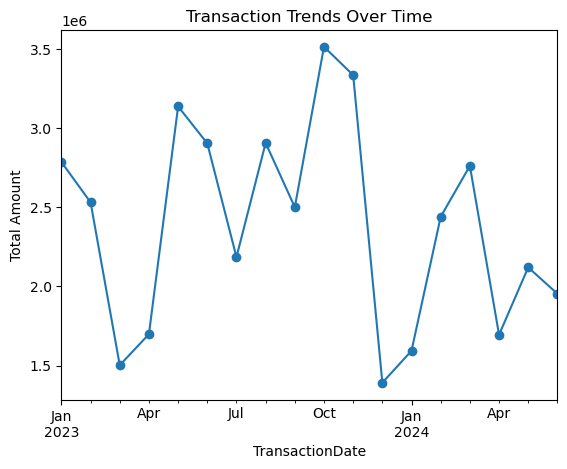

In [10]:
# Aggregating data for plotting
trends = df.groupby(df['TransactionDate'].dt.to_period('M'))['TransactionAmount'].sum()
trends.plot(kind='line', marker='o', title='Transaction Trends Over Time')
plt.ylabel('Total Amount')
plt.show()

In [11]:
# Net inflow = Deposits - (Withdrawals + Payments)
inflow = df.pivot_table(index='AccountID', columns='TransactionType', values='TransactionAmount', aggfunc='sum').fillna(0)
inflow['NetInflow'] = inflow.get('Deposit', 0) - (inflow.get('Withdrawal', 0) + inflow.get('Payment', 0))

top_accounts = inflow.sort_values(by='NetInflow', ascending=False).head(5)
bottom_accounts = inflow.sort_values(by='NetInflow', ascending=True).head(5)

print(top_accounts)

TransactionType        Deposit      Payment      Transfer   Withdrawal  \
AccountID                                                                
ACC92360         233048.539910  14658.77585  155317.66855      0.00000   
ACC21878         209175.590091      0.00000  122758.49821      0.00000   
ACC76549         192020.505780      0.00000   13505.71863      0.00000   
ACC39544         142078.535970      0.00000       0.00000      0.00000   
ACC80131         285053.477950  70599.52480  120993.44725  79614.00347   

TransactionType      NetInflow  
AccountID                       
ACC92360         218389.764060  
ACC21878         209175.590091  
ACC76549         192020.505780  
ACC39544         142078.535970  
ACC80131         134839.949680  


In [12]:
# Accounts with a gap of 2 months or more
df = df.sort_values(['AccountID', 'TransactionDate'])
df['DateDiff'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days

# Flagging accounts where the gap exceeds 60 days (approx 2 months)
dormant_accounts = df[df['DateDiff'] > 60]['AccountID'].unique()
print(f"Dormant Account IDs: {dormant_accounts}")

Dormant Account IDs: ['ACC10117' 'ACC10996' 'ACC11062' 'ACC11188' 'ACC11285' 'ACC11837'
 'ACC12182' 'ACC12334' 'ACC13357' 'ACC15228' 'ACC15359' 'ACC15925'
 'ACC16241' 'ACC16664' 'ACC17688' 'ACC18057' 'ACC19156' 'ACC19178'
 'ACC20297' 'ACC21264' 'ACC21429' 'ACC21719' 'ACC21878' 'ACC22036'
 'ACC22255' 'ACC22799' 'ACC23736' 'ACC23985' 'ACC24070' 'ACC24508'
 'ACC24880' 'ACC24981' 'ACC25132' 'ACC25811' 'ACC26026' 'ACC26940'
 'ACC26956' 'ACC26973' 'ACC28292' 'ACC28305' 'ACC28612' 'ACC29231'
 'ACC29356' 'ACC29396' 'ACC29477' 'ACC29646' 'ACC30146' 'ACC30787'
 'ACC30852' 'ACC31539' 'ACC31902' 'ACC32627' 'ACC32890' 'ACC33287'
 'ACC34119' 'ACC34431' 'ACC34568' 'ACC34821' 'ACC35163' 'ACC35419'
 'ACC36079' 'ACC37688' 'ACC39161' 'ACC39482' 'ACC39500' 'ACC39529'
 'ACC40939' 'ACC40952' 'ACC41829' 'ACC42467' 'ACC42710' 'ACC42903'
 'ACC45101' 'ACC45521' 'ACC45907' 'ACC45951' 'ACC45968' 'ACC46655'
 'ACC46953' 'ACC47099' 'ACC48501' 'ACC49140' 'ACC49180' 'ACC49364'
 'ACC49395' 'ACC49422' 'ACC49774' 'ACC504

Task 3

In [13]:
# Calculating transaction frequency
activity_counts = df.groupby('AccountID')['TransactionID'].count()

# Applying the rubric for activity levels
def get_activity_level(count):
    if count > 20: return 'High Activity'
    elif count >= 10: return 'Medium Activity'
    else: return 'Low Activity'

df['ActivityLevel'] = df['AccountID'].map(activity_counts.apply(get_activity_level))
print(df['ActivityLevel'].value_counts())

ActivityLevel
Low Activity       748
Medium Activity     52
Name: count, dtype: int64


In [14]:
segmentation = df.groupby('AccountID').agg({
    'AccountBalance': 'mean',
    'TransactionID': 'count'
}).rename(columns={'TransactionID': 'Volume', 'AccountBalance': 'AvgBalance'})
print(segmentation)

             AvgBalance  Volume
AccountID                      
ACC10117   97828.704775       4
ACC10996   56982.152538       5
ACC11062   65947.316965       2
ACC11188   81169.114065       4
ACC11285   62574.613950       3
...                 ...     ...
ACC97225   83082.318542       5
ACC97411   92986.563745       2
ACC99117   63718.264758       5
ACC99409   80812.930211       7
ACC99549   61264.768890       4

[193 rows x 2 columns]


In [15]:
# Filtering accounts with high net inflow (top 10%)
threshold_inflow = inflow.quantile(0.9)
high_inflow_profiles = inflow[inflow > threshold_inflow]
print(f"Identified {len(high_inflow_profiles)} High-net inflow accounts.")

Identified 193 High-net inflow accounts.


In [27]:
# High frequency (> median volume) and Low balance (< median balance)
median_vol = segmentation['Volume'].median()
median_bal = segmentation['AvgBalance'].median()

hf_lb_accounts = segmentation[(segmentation['Volume'] > median_vol) & (segmentation['AvgBalance'] < median_bal)]
print(f"High-frequency low-balance accounts: {len(hf_lb_accounts)}")

High-frequency low-balance accounts: 37


In [29]:
# Flagging accounts with balance below £100
near_zero_profiles = segmentation[segmentation['AvgBalance'] < 100]
print(f"Accounts with near-zero balances: {len(near_zero_profiles)}")

Accounts with near-zero balances: 0


Task 4

In [30]:
# Criterion: Withdrawal > 4000 or Account Balance < 0
large_withdrawals = df[(df['TransactionType'] == 'Withdrawal') & (df['TransactionAmount'] > 4000)]
overdraft_incidents = df[df['AccountBalance'] < 0]

print(f"Large withdrawals: {len(large_withdrawals)}, Overdraft incidents: {len(overdraft_incidents)}")

Large withdrawals: 200, Overdraft incidents: 14


In [31]:
# Measuring how much the account balance fluctuates
balance_volatility = df.groupby('AccountID')['AccountBalance'].std().fillna(0)
print("Balance Volatility (Top 5 volatile accounts):\n", balance_volatility.sort_values(ascending=False).head())

Balance Volatility (Top 5 volatile accounts):
 AccountID
ACC55331    73097.164038
ACC77592    70420.099530
ACC11285    70126.826097
ACC29646    70075.270756
ACC76699    66755.178766
Name: AccountBalance, dtype: float64


In [32]:
# Using Z-score to detect transaction amount anomalies (Threshold > 3)
df['Z_Score_Amount'] = stats.zscore(df['TransactionAmount'])
anomalies = df[df['Z_Score_Amount'].abs() > 3]
print(f"Statistical anomalies detected: {len(anomalies)}")

Statistical anomalies detected: 4


In [33]:
# Criteria for Suspicious Behavior: High Volatility + High Risk Score + Anomaly Flag
risk_threshold = df['RiskScore'].quantile(0.9) # Top 10% risk scores

suspicious_customers = df[
    (df['AccountID'].isin(anomalies['AccountID'])) & (df['RiskScore'] > risk_threshold)]['AccountID'].unique()

print(f"CUSTOMERS HIGHLIGHTED FOR INVESTIGATION: {list(suspicious_customers)}")

CUSTOMERS HIGHLIGHTED FOR INVESTIGATION: []


Task 5

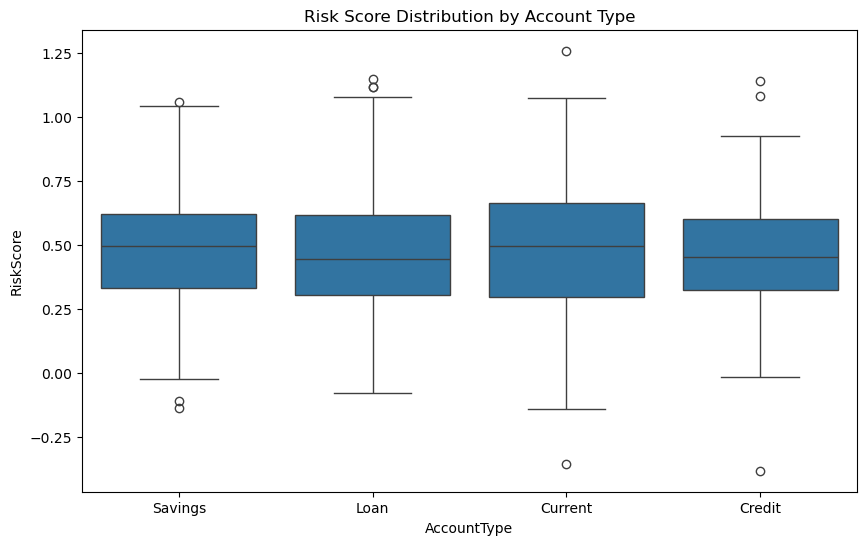

ValueError: Could not interpret value `Account Balance` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x='AccountType', y='RiskScore', data=df)
plt.title('Risk Score Distribution by Account Type')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='Account Balance', y='TransactionAmount', hue='TransactionType', data=df)
plt.title('Balance vs. Transaction Amount')
plt.show()

Task 6

In [35]:
# Define high volume as > 10 transactions
high_vol_ids = segmentation[segmentation['Volume'] > 10].index
low_vol_ids = segmentation[segmentation['Volume'] <= 10].index

high_vol_balances = df[df['AccountID'].isin(high_vol_ids)]['AccountBalance']
low_vol_balances = df[df['AccountID'].isin(low_vol_ids)]['AccountBalance']

t_stat, p_val = stats.ttest_ind(high_vol_balances, low_vol_balances)
print(f"P-Value: {p_val}") # If p < 0.05, the difference is statistically significant

P-Value: 0.5146817888704707


In [36]:
# Testing if Savings accounts have significantly different risk scores than Credit accounts
savings_risk = df[df['AccountType'] == 'Savings']['RiskScore']
credit_risk = df[df['AccountType'] == 'Credit']['RiskScore']

t_stat_risk, p_val_risk = stats.ttest_ind(savings_risk, credit_risk)
print(f"Risk Hypothesis P-Value: {p_val_risk:.4f}")

Risk Hypothesis P-Value: 0.2376
